<a href="https://colab.research.google.com/github/saulotorres7031-stack/Tareas1/blob/main/Loan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Paquetería básica
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Importamos Tensorflow y Keras
import tensorflow as tf
from tensorflow import keras

# Usamos funcionalidades básicas de Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
!wget 'https://github.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/raw/main/Datasets/loan_prediction.csv'

--2026-03-14 19:10:32--  https://github.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/raw/main/Datasets/loan_prediction.csv
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/main/Datasets/loan_prediction.csv [following]
--2026-03-14 19:10:32--  https://raw.githubusercontent.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/main/Datasets/loan_prediction.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17516 (17K) [text/plain]
Saving to: ‘loan_prediction.csv.2’

loan_prediction.csv 100%[===================>]  17.11K  --.-KB/s    in 0s   

In [3]:
dataset = pd.read_csv('loan_prediction.csv')
dataset.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
0,5849,0.0,0.0,360.0,1.0,1
1,4583,1508.0,128.0,360.0,1.0,0
2,3000,0.0,66.0,360.0,1.0,1
3,2583,2358.0,120.0,360.0,1.0,1
4,6000,0.0,141.0,360.0,1.0,1


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ApplicantIncome    614 non-null    int64  
 1   CoapplicantIncome  614 non-null    float64
 2   LoanAmount         614 non-null    float64
 3   Loan_Amount_Term   614 non-null    float64
 4   Credit_History     614 non-null    float64
 5   Loan_Status        614 non-null    int64  
dtypes: float64(4), int64(2)
memory usage: 28.9 KB


In [5]:
np.array(dataset)

array([[5.849e+03, 0.000e+00, 0.000e+00, 3.600e+02, 1.000e+00, 1.000e+00],
       [4.583e+03, 1.508e+03, 1.280e+02, 3.600e+02, 1.000e+00, 0.000e+00],
       [3.000e+03, 0.000e+00, 6.600e+01, 3.600e+02, 1.000e+00, 1.000e+00],
       ...,
       [8.072e+03, 2.400e+02, 2.530e+02, 3.600e+02, 1.000e+00, 1.000e+00],
       [7.583e+03, 0.000e+00, 1.870e+02, 3.600e+02, 1.000e+00, 1.000e+00],
       [4.583e+03, 0.000e+00, 1.330e+02, 3.600e+02, 0.000e+00, 0.000e+00]])

One-Hot

In [6]:
changes = dataset.pop('Credit_History')
dataset['1'] = (changes == 1)*1.0
dataset['0'] = (changes == 0)*1.0
dataset.tail()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Loan_Status,1,0
609,2900,0.0,71.0,360.0,1,1.0,0.0
610,4106,0.0,40.0,180.0,1,1.0,0.0
611,8072,240.0,253.0,360.0,1,1.0,0.0
612,7583,0.0,187.0,360.0,1,1.0,0.0
613,4583,0.0,133.0,360.0,0,0.0,1.0


Variables de entrada y salida

In [7]:
x = np.asanyarray(dataset.drop(columns=['Loan_Status']))
y = np.asanyarray(dataset[['Loan_Status']])
x = StandardScaler().fit_transform(x)
print(x.shape)
print(y.shape)

(614, 6)
(614, 1)


Particionar el dataset

In [8]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2,stratify=y)

Red neuronal para aprender los datos. En este caso creamos la metrica de regresión R2,

In [9]:
def build_model():

  model = keras.Sequential()
  model.add(keras.layers.Dense(64, activation='relu', input_shape=[x.shape[1]]))
  model.add(keras.layers.Dense(32, activation='relu'))
  model.add(keras.layers.Dropout(0.4))
  model.add(keras.layers.Dense(16, activation='relu'))
  #model.add(keras.layers.Dropout(0.6))
  model.add(keras.layers.Dense(1, activation='sigmoid'))

  model.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(),
    metrics=[
        keras.metrics.AUC(name='auc')])
  return  model

In [10]:
es = keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=80)

model = build_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Red neuronal sin Early stopping

In [11]:
history = model.fit(xtrain, ytrain,
                    batch_size=150, epochs=500,
                    validation_data=(xtest, ytest), verbose=0)

Dibuja las curvas de aprendizaje para un mejor diagnóstico del aprendizaje

In [12]:
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch
  plt.figure()
  plt.subplot(121)
  plt.title('Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.plot(hist['epoch'], hist['loss'],
           label='Train')
  plt.plot(hist['epoch'], hist['val_loss'],
           label = 'Val')
  plt.yscale('log')
  plt.legend()

  plt.subplot(122)
  plt.title('Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('auc')
  plt.plot(hist['epoch'], hist['auc'],
           label='Train')
  plt.plot(hist['epoch'], hist['val_auc'],
           label = 'Val')
  plt.ylim([0,1])
  plt.legend()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - auc: 0.7488 - loss: 0.5626
Acccuracy: 0.7487615942955017
Loss: 0.5626397728919983
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - auc: 0.9043 - loss: 0.3463
Acccuracy: 0.9043025970458984
Loss: 0.3463129997253418


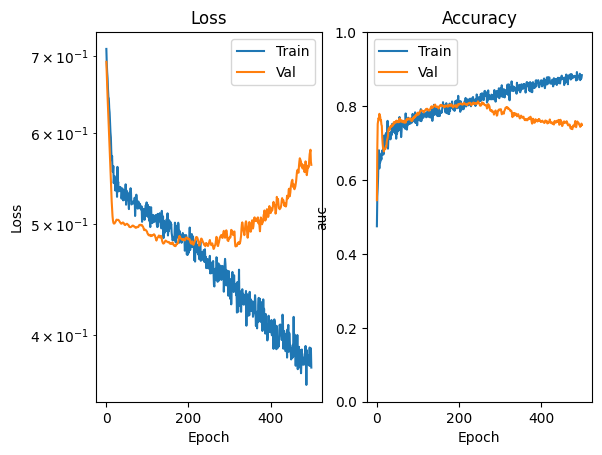

In [13]:
plot_history(history)

loss,accuracy = model.evaluate(xtest, ytest, batch_size=150)

print("Acccuracy:", accuracy)
print("Loss:", loss)

loss,accuracy = model.evaluate(xtrain, ytrain, batch_size=150)

print("Acccuracy:", accuracy)
print("Loss:", loss)

Con Early Stopping

In [14]:
model2 = build_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
history2 = model2.fit(xtrain, ytrain,
                    batch_size=150, epochs=500,
                    validation_data=(xtest, ytest),
                    verbose=0, callbacks=[es])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - auc: 0.7509 - loss: 0.5108
Acccuracy: 0.7509288191795349
Loss: 0.5108150243759155
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - auc: 0.8344 - loss: 0.4496
Acccuracy: 0.8343867063522339
Loss: 0.4495730698108673


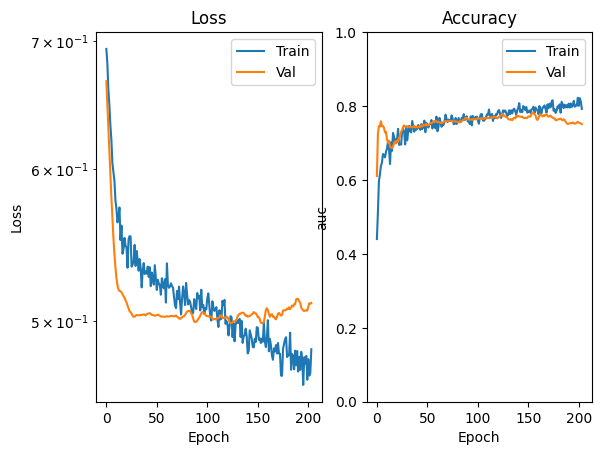

In [16]:
plot_history(history2)

loss,accuracy = model2.evaluate(xtest, ytest, batch_size=150)

print("Acccuracy:", accuracy)
print("Loss:", loss)

loss,accuracy = model2.evaluate(xtrain, ytrain, batch_size=150)

print("Acccuracy:", accuracy)
print("Loss:", loss)